In [ ]:
import os
from dotenv import load_dotenv

In [ ]:
load_dotenv()

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")



Установка и первый граф

    Установить LangGraph.

    Создать простейший DAG с тремя узлами, которые выполняются последовательно и передают данные друг другу.



In [6]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel


class MyState(BaseModel):
    data: str = ""


def node1(state: MyState):
    print("Working state 1")
    return {"data": "Node 1 data"}


def node2(state: MyState):
    print("Working state 2")
    new_data = state.data + " -> Node 2 data"
    return {"data": new_data}


def node3(state: MyState):
    print("Working state 3")
    new_data = state.data + " -> Node 3 data"
    return {"data": new_data}


builder = StateGraph(MyState)

builder.add_node("Node1", node1)
builder.add_node("Node2", node2)
builder.add_node("Node3", node3)

builder.add_edge(START, "Node1")
builder.add_edge("Node1", "Node2")
builder.add_edge("Node2", "Node3")
builder.add_edge("Node3", END)

graph = builder.compile()

initial_state = MyState()
final_state = graph.invoke(initial_state)

print("Result:", final_state['data'])

Working state 1
Working state 2
Working state 3
Result: Node 1 data -> Node 2 data -> Node 3 data




Добавление параметров и передача данных

    В первом узле сгенерировать число.

    Во втором узле увеличить число на 10.

    В третьем узле вывести результат.



In [9]:
import random

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel


class MyState(BaseModel):
    number: int = 0


def m_gennum(state: MyState):
    number = random.randint(0, 100)
    print(f"[*] Create number {number}")
    state.number = number
    return state

def m_plus10(state: MyState):
    print("[*] Plus 10")
    state.number += 10
    return state

def m_showres(state: MyState):
    print("[*] Result:", state.number)
    return state


builder = StateGraph(MyState)

builder.add_node("Node1", m_gennum)
builder.add_node("Node2", m_plus10)
builder.add_node("Node3", m_showres)

builder.add_edge(START, "Node1")
builder.add_edge("Node1", "Node2")
builder.add_edge("Node2", "Node3")
builder.add_edge("Node3", END)

graph = builder.compile()

initial_state = MyState()
final_state = graph.invoke(initial_state)

print("Result number:", final_state["number"])

[*] Create number 94
[*] Plus 10
[*] Result: 104
Result number: 104




Простой асинхронный граф

    Создать два узла, которые запускаются параллельно и делают разные вычисления (например, возводят число в квадрат и куб).

    Объединить результаты в следующем узле.



In [26]:
import asyncio
from typing import Optional
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel


class State(BaseModel):
    number: int
    square: Optional[int] = None
    cube: Optional[int] = None
    combine: Optional[int] = None


async def square(state: State):
    return { "square" : state.number * state.number }


async def cube(state: State):
    return { "cube" : state.number * state.number * state.number }


async def combine(state: State):
    return { "combine" : state.square + state.cube }


builder = StateGraph(State)

builder.add_node("Square", square)
builder.add_node("Cube", cube)
builder.add_node("Combine", combine)

builder.add_edge(START, "Square")
builder.add_edge(START, "Cube")
builder.add_edge("Square", "Combine")
builder.add_edge("Cube", "Combine")
builder.add_edge("Combine", END)

graph = builder.compile()
init_state = State(number=3)

res = await graph.ainvoke(init_state)
res

{'number': 3, 'square': 9, 'cube': 27, 'combine': 36}



Обработка ошибок

    Спроектировать узел, который может случайно выбросить исключение.

    Добавить базовую обработку ошибок с повтором выполнения.



In [57]:
from typing import Optional
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel


class State(BaseModel):
    number: Optional[int] = None
    check_res: Optional[str] = None
    answer: Optional[int] = None


def check_handler(state: State):
    res = "correct" if state.number > 90 else "wrong"
    return { "check_res": res }


def check_condition(state: State):
    return state.check_res


def get_rand(state: State):
    import random
    number = random.randint(0, 100)
    print("Number:", number)
    return { "number": number }


def get_answer_g90(state: State):
    return { "answer": state.number }


builder = StateGraph(State)

builder.add_node("GenRand", get_rand)
builder.add_node("CheckNumber", check_handler)
builder.add_node("AnswerG90", get_answer_g90)

builder.add_edge(START, "GenRand")
builder.add_edge("GenRand", "CheckNumber")
builder.add_conditional_edges(
    "CheckNumber",
    check_condition,
    {
        "correct": "AnswerG90",
        "wrong": "GenRand"
    }
)
builder.add_edge("AnswerG90", END)

graph = builder.compile()
init_state = State()

res = graph.invoke(
    init_state,
    {"recursion_limit": 1000}    
)
res

Number: 62
Number: 91


{'number': 91, 'check_res': 'correct', 'answer': 91}



Локальное сохранение состояния

    Добавить в граф память, которая сохраняет промежуточные результаты и использует их в следующих узлах.



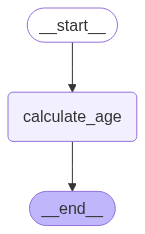

In [1]:
from datetime import date
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class UserState(TypedDict):
    name: str
    surname: str
    age: int
    birth_date: date


def calculate_age(state: UserState) -> UserState:
    today = date.today()
    age = today.year - state["birth_date"].year
    if (today.month, today.day) < (state["birth_date"].month, state["birth_date"].day):
        age -= 1
    state["age"] = age
    return state


graph = StateGraph(UserState)

graph.add_node("calculate_age", calculate_age)

graph.add_edge(START, "calculate_age")
graph.add_edge("calculate_age", END)

app = graph.compile()

result = app.invoke({
    "name": "Алексей",
    "surname": "Яковенко",
    "birth_date": date.fromisoformat("1993-02-19")
})
print(result)

{'name': 'Алексей', 'surname': 'Яковенко', 'age': 32, 'birth_date': datetime.date(1993, 2, 19)}


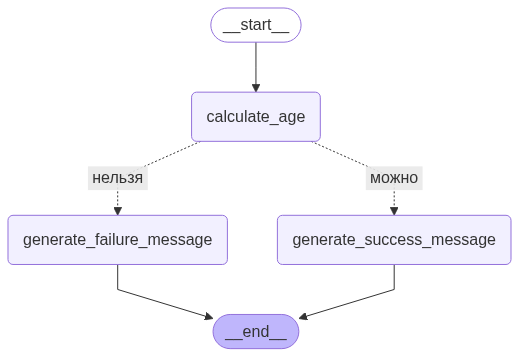

In [2]:
from typing import TypedDict
from datetime import date


class UserState(TypedDict):
    name: str
    surname: str
    age: int
    birth_date: date
    message: str  # Новое поле для хранения сообщения пользователю


def calculate_age(state: UserState) -> UserState:
    today = date.today()
    age = today.year - state["birth_date"].year
    if (today.month, today.day) < (state["birth_date"].month, state["birth_date"].day):
        age -= 1
    state["age"] = age
    return state


def generate_success_message(state: UserState) -> dict:
    return {
        "message": f"Поздравляем, {state['name']} {state['surname']}! "
                   f"Вам уже {state['age']} лет и вы можете водить!"
    }

def generate_failure_message(state: UserState) -> dict:
    return {
        "message": f"К сожалению, {state['name']} {state['surname']}, "
                   f"вам ещё только {state['age']} лет и вы не можете водить."
    }


def check_drive(state: UserState) -> str:
    if state["age"] >= 18:
        return "можно"
    else:
        return "нельзя"


graph = StateGraph(UserState)

graph.add_node("calculate_age", calculate_age)
graph.add_node("generate_success_message", generate_success_message)
graph.add_node("generate_failure_message", generate_failure_message)

graph.add_edge(START, "calculate_age")
graph.add_conditional_edges(
    "calculate_age", 
    check_drive, 
    {
        "можно": "generate_success_message", 
        "нельзя": "generate_failure_message"
    }
)
graph.add_edge("generate_success_message", END)
graph.add_edge("generate_failure_message", END)

app = graph.compile()
result = app.invoke({
    "name": "Алексей",
    "surname": "Яковенко",
    "birth_date": date.fromisoformat("1993-02-19")
})

print(result)

{'name': 'Алексей', 'surname': 'Яковенко', 'age': 32, 'birth_date': datetime.date(1993, 2, 19), 'message': 'Поздравляем, Алексей Яковенко! Вам уже 32 лет и вы можете водить!'}


In [6]:
from typing import TypedDict
from datetime import date, timedelta


class UserState(TypedDict):
    name: str
    surname: str
    age: int
    birth_date: date
    today: date  # Новое поле для хранения "текущей" даты
    message: str


def calculate_age(state: UserState) -> dict:
    """
    Вычисляет точный возраст человека от переданной даты.
    """
    today = state["today"]  # Берём дату из состояния, а не системную
    # Вычисляем разность в годах
    age = today.year - state["birth_date"].year
    # Проверяем, прошёл ли уже день рождения в этом году
    if (today.month, today.day) < (state["birth_date"].month, state["birth_date"].day):
        age -= 1
    return {"age": age}


def generate_success_message(state: UserState) -> dict:
    return {
        "message": f"Поздравляем, {state['name']} {state['surname']}! "
                   f"Вам уже {state['age']} лет и вы можете водить!"
    }


def check_drive(state: UserState) -> str:
    if state["age"] >= 18:
        return "можно"
    else:
        return "нельзя"


def autoincrement_date(state: UserState) -> dict:
    """
    Увеличивает текущую дату на один день.
    """
    current_date = state["today"]
    new_date = current_date + timedelta(days=1)
    print(f"{current_date} -> {new_date}")  # Для наглядности процесса
    return {"today": new_date}


graph = StateGraph(UserState)

graph.add_node("calculate_age", calculate_age)
graph.add_node("autoincrement_date", autoincrement_date)
graph.add_node("generate_success_message", generate_success_message)

graph.add_edge(START, "calculate_age")
graph.add_conditional_edges(
    "calculate_age", 
    check_drive, 
    {
        "можно": "generate_success_message", 
        "нельзя": "autoincrement_date"
    }
)
graph.add_edge("autoincrement_date", "calculate_age")
graph.add_edge("generate_success_message", END)

app = graph.compile()
result = app.invoke({
    "name": "Алексей",
    "surname": "Яковенко",
    "birth_date": date.fromisoformat("2009-02-19"),  # Несовершеннолетний
    "today": date.today()
}, {"recursion_limit": 1000})

print(result)

2025-10-22 -> 2025-10-23
2025-10-23 -> 2025-10-24
2025-10-24 -> 2025-10-25
2025-10-25 -> 2025-10-26
2025-10-26 -> 2025-10-27
2025-10-27 -> 2025-10-28
2025-10-28 -> 2025-10-29
2025-10-29 -> 2025-10-30
2025-10-30 -> 2025-10-31
2025-10-31 -> 2025-11-01
2025-11-01 -> 2025-11-02
2025-11-02 -> 2025-11-03
2025-11-03 -> 2025-11-04
2025-11-04 -> 2025-11-05
2025-11-05 -> 2025-11-06
2025-11-06 -> 2025-11-07
2025-11-07 -> 2025-11-08
2025-11-08 -> 2025-11-09
2025-11-09 -> 2025-11-10
2025-11-10 -> 2025-11-11
2025-11-11 -> 2025-11-12
2025-11-12 -> 2025-11-13
2025-11-13 -> 2025-11-14
2025-11-14 -> 2025-11-15
2025-11-15 -> 2025-11-16
2025-11-16 -> 2025-11-17
2025-11-17 -> 2025-11-18
2025-11-18 -> 2025-11-19
2025-11-19 -> 2025-11-20
2025-11-20 -> 2025-11-21
2025-11-21 -> 2025-11-22
2025-11-22 -> 2025-11-23
2025-11-23 -> 2025-11-24
2025-11-24 -> 2025-11-25
2025-11-25 -> 2025-11-26
2025-11-26 -> 2025-11-27
2025-11-27 -> 2025-11-28
2025-11-28 -> 2025-11-29
2025-11-29 -> 2025-11-30
2025-11-30 -> 2025-12-01


В продакшн-окружении параметры лимита рекурсии лучше выносить в конфигурационные файлы. Это позволяет гибко управлять поведением агентов без изменения кода.

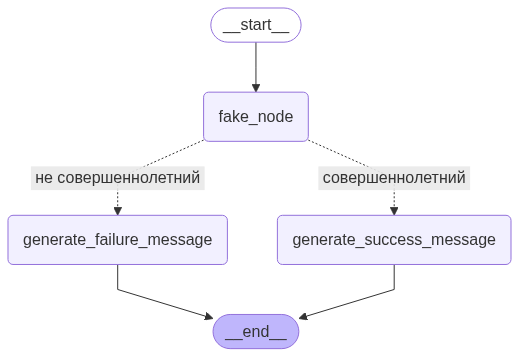

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class UserState(TypedDict):
    age: int
    message: str


def check_age(state: UserState) -> str:
    """Условная функция для проверки возраста"""
    return "совершеннолетний" if state["age"] >= 18 else "не_совершеннолетний"


def generate_success_message(state: UserState) -> dict:
    """Генерирует сообщение для совершеннолетних"""
    return {"message": f"Вам уже {state['age']} лет и вы можете водить!"}


def generate_failure_message(state: UserState) -> dict:
    """Генерирует сообщение для несовершеннолетних"""
    return {"message": f"Вам ещё только {state['age']} лет и вы не можете водить."}


graph = StateGraph(UserState)

# Фиктивный узел - просто передаёт состояние дальше
graph.add_node("fake_node", lambda state: state)

# Основные узлы обработки
graph.add_node("generate_success_message", generate_success_message)
graph.add_node("generate_failure_message", generate_failure_message)

# Связываем START с фиктивным узлом
graph.add_edge(START, "fake_node")

# От фиктивного узла идёт условное ребро
graph.add_conditional_edges(
    "fake_node", 
    check_age, 
    {
        "совершеннолетний": "generate_success_message",
        "не_совершеннолетний": "generate_failure_message"
    }
)

# Завершаем оба пути
graph.add_edge("generate_success_message", END)
graph.add_edge("generate_failure_message", END)

app = graph.compile()

# Тест для несовершеннолетнего
result_minor = app.invoke({"age": 17})
print("Результат для 17 лет:", result_minor)

# Тест для совершеннолетнего  
result_adult = app.invoke({"age": 25})
print("Результат для 25 лет:", result_adult)

Результат для 17 лет: {'age': 17, 'message': 'Вам ещё только 17 лет и вы не можете водить.'}
Результат для 25 лет: {'age': 25, 'message': 'Вам уже 25 лет и вы можете водить!'}


## Визуализация

In [8]:
def gen_png_graph(app_obj, name_photo: str = "graph.png") -> None:
    """
    Генерирует PNG-изображение графа и сохраняет его в файл.
    
    Args:
        app_obj: Скомпилированный объект графа
        name_photo: Имя файла для сохранения (по умолчанию "graph.png")
    """
    with open(name_photo, "wb") as f:
        f.write(app_obj.get_graph().draw_mermaid_png())

In [9]:
# Компилируем граф
app = graph.compile()

# Генерируем визуализацию
gen_png_graph(app, name_photo="graph_example_4.png")

print("Граф сохранён как graph_example_4.png")

Граф сохранён как graph_example_4.png


## Простой диалоговый агент

In [ ]:
# START → [Ввод пользователя] → [Ответ ИИ] → [Проверка продолжения]
#                                 ↑                      ↓
#                                 └─── Продолжить ←──────┘

#                                      Завершить → END

In [22]:
from dotenv import load_dotenv
from langchain.chat_models import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from typing import List
from pydantic import BaseModel

# Выгружаем переменные окружения
load_dotenv()

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENROUTER_API_KEY,
    model_name="gpt-4o-mini"
)


class ChatState(BaseModel):
    messages: List[BaseMessage] = None
    should_continue: bool = True


def user_input_node(state: ChatState) -> dict:
    """Узел для получения ввода пользователя"""
    user_input = input("Вы: ")

    # Проверяем команды выхода
    #  В реальной практике решение об остановке диалога вполне может принимать нейросеть. Вопрос в правильной настройке
    if user_input.lower() in ["выход", "quit", "exit", "пока", "bye"]:
        return {"should_continue": False}

    # Добавляем сообщение пользователя
    new_messages = state.messages + [HumanMessage(content=user_input)]  # не мутируем существующий список сообщений, а создаём новый. Это соответствует принципам функционального программирования и предотвращает неожиданные побочные эффекты
    return {"messages": new_messages, "should_continue": True}


def trim_context_if_needed(messages: List[BaseMessage], max_messages: int = 20) -> List[BaseMessage]:
    """Обрезаем контекст, если он становится слишком длинным"""
    if len(messages) <= max_messages:
        return messages

    # Сохраняем системные сообщения + последние сообщения диалога
    system_msgs = [msg for msg in messages if isinstance(msg, SystemMessage)]
    dialog_msgs = [msg for msg in messages if not isinstance(msg, SystemMessage)]

    recent_msgs = dialog_msgs[-(max_messages - len(system_msgs)):]
    return system_msgs + recent_msgs

  
def optimized_llm_response_node(state: ChatState) -> dict:
    """Оптимизированный узел с контролем длины контекста"""
    # Обрезаем контекст при необходимости
    trimmed_messages = trim_context_if_needed(state["messages"])

    response = llm.invoke(trimmed_messages)
    msg_content = response.content
    print(f"ИИ: {msg_content}")

    new_messages = state["messages"] + [AIMessage(content=msg_content)]
    return {"messages": new_messages}


def llm_response_node(state: ChatState) -> dict:
    # """Узел для генерации ответа ИИ"""
    # # Получаем ответ от LLM, передавая весь контекст
    # response = llm.invoke(state.messages)
    # msg_content = response.content

    # # Выводим ответ
    # print(f"ИИ: {msg_content}")

    # # Добавляем ответ в историю как AIMessage
    # new_messages = state.messages + [AIMessage(content=msg_content)]
    # return {"messages": new_messages}

    """Узел с обработкой ошибок и повторными попытками"""
    max_retries = 3

    for attempt in range(max_retries):
        try:
            response = llm.invoke(state.messages)
            msg_content = response.content
            print(f"ИИ: {msg_content}")

            new_messages = state.messages + [AIMessage(content=msg_content)]
            return {"messages": new_messages}

        except Exception as e:
            if attempt == max_retries - 1:
                # Последняя попытка — возвращаем ошибку пользователю
                error_msg = "Извините, произошла ошибка. Попробуйте ещё раз."
                print(f"ИИ: {error_msg}")
                new_messages = state.messages + [AIMessage(content=error_msg)]
                return {"messages": new_messages}
            else:
                print(f"Попытка {attempt + 1} неудачна, повторяю...")
                continue


def should_continue(state: ChatState) -> str:
    """Условная функция для определения продолжения диалога"""
    return "continue" if state.should_continue else "end"


# Создаём граф
graph = StateGraph(ChatState)

# Добавляем узлы
graph.add_node("user_input", user_input_node)
graph.add_node("llm_response", llm_response_node)

# Создаём рёбра
graph.add_edge(START, "user_input")
graph.add_edge("user_input", "llm_response")

# Условное ребро для проверки продолжения
graph.add_conditional_edges(
    "llm_response",
    should_continue,
    {
        "continue": "user_input",  # Возвращаемся к вводу пользователя
        "end": END                 # Завершаем диалог
    }
)

# Компиляция графа
app = graph.compile()

print("Добро пожаловать в чат с ИИ!")
print("Для выхода введите: выход, quit, exit, пока, или bye")
print("-" * 50)

# Начальное состояние с системным сообщением
initial_state = {
    "messages": [
        SystemMessage(
            content="Ты дружелюбный помощник. Отвечай коротко и по делу."
        )
    ],
    "should_continue": True
}

try:
    # Запуск чата
    final_state = app.invoke(initial_state)

    print("-" * 50)
    print("Чат завершён. До свидания!")
    print(f"Всего сообщений в диалоге: {len(final_state['messages'])}")

except KeyboardInterrupt:
    print("\n\nЧат прерван пользователем (Ctrl+C)")
except Exception as e:
    print(f"\nОшибка в работе чата: {e}")

Добро пожаловать в чат с ИИ!
Для выхода введите: выход, quit, exit, пока, или bye
--------------------------------------------------
ИИ: Привет! Как могу помочь?
ИИ: Как я могу помочь?
--------------------------------------------------
Чат завершён. До свидания!
Всего сообщений в диалоге: 4


> Выше я указал простой и лаконичный пример хранения сообщений от ИИ, но в реальных системах стоит сохранять полный AIMessage объект вместо извлечения только текста. Дело в том, что response содержит важные метаданные: информацию о потраченных токенах, времени выполнения запроса и, что критически важно для будущих инструментов, данные о вызовах внешних функций. Для учебных примеров текущий подход идеален, но в production лучше использовать new_messages = state["messages"] + [response] — это поможет при отладке и мониторинге.

#### Что может пойти не так: типичные ошибки

###### Ошибка 1: Мутация состояния

In [ ]:
#  Неправильно - мутируем существующий список
def bad_user_input_node(state: ChatState) -> dict:
    user_input = input("Вы: ")
    state["messages"].append(HumanMessage(content=user_input))  # Мутация!
    return state

# Правильно - создаём новый список
def good_user_input_node(state: ChatState) -> dict:
    user_input = input("Вы: ")
    new_messages = state["messages"] + [HumanMessage(content=user_input)]
    return {"messages": new_messages}

###### Ошибка 2: Потеря системного контекста

In [ ]:
# Неправильно - можем потерять SystemMessage
def bad_trim_context(messages: List[BaseMessage]) -> List[BaseMessage]:
    return messages[-10:]  # Просто берём последние 10

# Правильно - сохраняем системные сообщения
def good_trim_context(messages: List[BaseMessage]) -> List[BaseMessage]:
    system_msgs = [msg for msg in messages if isinstance(msg, SystemMessage)]
    dialog_msgs = [msg for msg in messages if not isinstance(msg, SystemMessage)]
    return system_msgs + dialog_msgs[-8:]  # Система + последние 8 диалоговых

###### Ошибка 3: Неправильная обработка пустого ввода

In [ ]:
# Неправильно - не обрабатываем пустые сообщения
def bad_user_input_node(state: ChatState) -> dict:
    user_input = input("Вы: ")
    new_messages = state["messages"] + [HumanMessage(content=user_input)]
    return {"messages": new_messages, "should_continue": True}

# Правильно - проверяем пустой ввод
def good_user_input_node(state: ChatState) -> dict:
    user_input = input("Вы: ").strip()

    if not user_input:  # Пустое сообщение
        print("Пожалуйста, введите сообщение.")
        return state  # Возвращаем состояние без изменений

    if user_input.lower() in ["выход", "quit", "exit", "пока", "bye"]:
        return {"should_continue": False}

    new_messages = state["messages"] + [HumanMessage(content=user_input)]
    return {"messages": new_messages, "should_continue": True}

#### Альтернативные подходы к управлению диалогом

###### ИИ принимает решение о завершении

In [ ]:
def ai_controlled_continuation_node(state: ChatState) -> dict:
    """ИИ сам решает, нужно ли завершить диалог"""

    # Добавляем специальный промпт для принятия решения
    decision_messages = state["messages"] + [
        HumanMessage(
            content="Проанализируй диалог. Если пользователь явно хочет завершить беседу "
                   "или диалог исчерпан, ответь ТОЛЬКО словом 'ЗАВЕРШИТЬ'. "
                   "Иначе продолжи обычный разговор."
        )
    ]

    response = llm.invoke(decision_messages)

    if "ЗАВЕРШИТЬ" in response.content.upper():
        print("ИИ: Было приятно пообщаться! До свидания!")
        return {"should_continue": False}
    else:
        # Обычный ответ
        print(f"ИИ: {response.content}")
        new_messages = state["messages"] + [AIMessage(content=response.content)]
        return {"messages": new_messages, "should_continue": True}

## Структурированные JSON-ответы: как всегда получать то, что ждешь

In [24]:
from pydantic import BaseModel, Field
from typing import List, Literal


class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        description="Тональность отзыва: положительная, отрицательная или нейтральная"
    )
    confidence: float = Field(
        description="Уверенность в анализе от 0.0 до 1.0",
        ge=0.0,  # больше или равно 0
        le=1.0   # меньше или равно 1
    )
    key_topics: List[str] = Field(
        description="Ключевые темы, упомянутые в отзыве",
        max_items=5
    )
    summary: str = Field(
        description="Краткое резюме отзыва в одном предложении",
        max_length=200
    )

C:\Users\Tumbi\AppData\Local\Temp\ipykernel_20176\1560327650.py:14: PydanticDeprecatedSince20: `max_items` is deprecated and will be removed, use `max_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  key_topics: List[str] = Field(


In [ ]:
from langchain_core.output_parsers import JsonOutputParser

# Создаем парсер на основе нашей модели
parser = JsonOutputParser(pydantic_object=SentimentAnalysis)

print("Что генерирует парсер:")
print(parser.get_format_instructions())  # Эти инструкции нейросеть понимает намного лучше, чем наши человеческие объяснения типа "верни JSON".

Что генерирует парсер:
The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"sentiment": {"description": "Тональность отзыва: положительная, отрицательная или нейтральная", "enum": ["positive", "negative", "neutral"], "title": "Sentiment", "type": "string"}, "confidence": {"description": "Уверенность в анализе от 0.0 до 1.0", "maximum": 1.0, "minimum": 0.0, "title": "Confidence", "type": "number"}, "key_topics": {"description": "Ключевые темы, упомянутые в отзыве", "items": {"type": "string"}, "maxItems": 5, "title": "Key Topics", "type": "array"}, "summary": {"description": "Кра

In [29]:
# Неудобно и не масштабируется
def create_prompt(review, format_instructions):
    return f"""Проанализируй отзыв: {review}
    
{format_instructions}

ТОЛЬКО JSON!"""

review_text = '''
{
  "sentiment": "positive",
  "confidence": 0.85,
  "key_topics": ["качество", "доставка"]
}
'''
instructions = parser.get_format_instructions()

# При каждом использовании нужно помнить порядок параметров
prompt1 = create_prompt(review_text, instructions)  # Правильно
# prompt2 = create_prompt(instructions, review_text)  # Ошибка!

In [30]:
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    template="""Проанализируй отзыв: {review}

{format_instructions}

ТОЛЬКО JSON!""",
    input_variables=["review"], # Что должен предоставить пользователь
    partial_variables={         # Что заполняется автоматически
        "format_instructions": parser.get_format_instructions()
    }
)

In [31]:
# Способ 1: format() — возвращает обычную строку
formatted_text = prompt_template.format(review="Отличный товар!")

# Способ 2: invoke() — возвращает специальный PromptValue объект
prompt_value = prompt_template.invoke({"review": "Отличный товар!"})

# Способ 3: в цепочке (самый элегантный)
chain = prompt_template | llm | parser

In [32]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENROUTER_API_KEY,
    model_name="gpt-4o-mini",
    temperature=0.0
)

In [33]:
# Тестовый отзыв
review = "Товар отличный, быстрая доставка! Очень доволен покупкой."

print("=== ПОШАГОВОЕ ВЫПОЛНЕНИЕ ===")

# Шаг 1: Применяем шаблон
print("Применяем PromptTemplate")
prompt_value = prompt_template.invoke({"review": review})
print(f"Тип: {type(prompt_value)}")

# Посмотрим на готовый промпт
prompt_text = prompt_value.to_string()
print("Готовый промпт:")
print(prompt_text[:200] + "...")  # Первые 200 символов
print()

# Шаг 2: Отправляем в нейросеть
print("Отправляем в нейросеть")
llm_response = llm.invoke(prompt_value)
print(f"Тип ответа: {type(llm_response)}")
print(f"Ответ: {llm_response.content}")
print()

# Шаг 3: Парсим JSON
print("Парсим JSON")
parsed_result = parser.invoke(llm_response)
print(f"Тип результата: {type(parsed_result)}")
print("Структурированные данные:")
for key, value in parsed_result.items():
    print(f"  {key}: {value}")

=== ПОШАГОВОЕ ВЫПОЛНЕНИЕ ===
Применяем PromptTemplate
Тип: <class 'langchain_core.prompt_values.StringPromptValue'>
Готовый промпт:
Проанализируй отзыв: Товар отличный, быстрая доставка! Очень доволен покупкой.

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema...

Отправляем в нейросеть
Тип ответа: <class 'langchain_core.messages.ai.AIMessage'>
Ответ: ```json
{
  "sentiment": "positive",
  "confidence": 0.95,
  "key_topics": [
    "товар",
    "доставка",
    "покупка",
    "удовлетворенность"
  ],
  "summary": "Покупатель очень доволен качеством товара и быстрой доставкой."
}
```

Парсим JSON
Тип результата: <class 'dict'>
Структурированные данные:
  sentiment: positive
  confidence: 0.95
  key_topics: ['товар', 'доставка', 'покупка', 'удовлетворенность']
  summary: Покупатель очень доволен качеством товара и быстрой доставкой.


In [34]:
# Лаконичный способ через цепочку:
# Все в одну строку
analysis_chain = prompt_template | llm | parser
result = analysis_chain.invoke({"review": review})

print("=== ЧЕРЕЗ ЦЕПОЧКУ ===")
print(f"Результат: {result}")

=== ЧЕРЕЗ ЦЕПОЧКУ ===
Результат: {'sentiment': 'positive', 'confidence': 0.95, 'key_topics': ['товар', 'доставка', 'покупка', 'удовлетворенность'], 'summary': 'Покупатель очень доволен качеством товара и быстрой доставкой.'}


#### интеграция в LangGraph

Суть задачи будет сводиться к следующему:

    В интерактивном формате пользователь будет писать сообщения

    Нейросеть должна будет определять — это отзыв или просто обычное сообщение (вопрос)

    В случае если это отзыв — запускаем анализ с получением структурированного JSON

    В случае если это вопрос — даем обычный ответ чат-бота

In [35]:
# START → [Ввод пользователя] → [Классификация ИИ]
#                                       ↓
#                               ┌─── Отзыв? ───┐
#                               ↓              ↓
#                     [Анализ отзыва]    [Ответ на вопрос]
#                          ↓                   ↓
#                     [JSON результат]   [Обычный чат]
#                          ↓                   ↓
#                          └─── [Продолжить] ──┘
#                                       ↓
#                                 [Новый ввод] или END

In [36]:
from pydantic import BaseModel, Field
from typing import List, Literal


# Модель для классификации сообщения
class MessageClassification(BaseModel):
    message_type: Literal["review", "question"] = Field(
        description="Тип сообщения: отзыв или вопрос"
    )
    confidence: float = Field(
        description="Уверенность в классификации от 0.0 до 1.0",
        ge=0.0, le=1.0
    )


# Модель для анализа отзыва
class ReviewAnalysis(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"] = Field(
        description="Тональность отзыва"
    )
    confidence: float = Field(
        description="Уверенность в анализе от 0.0 до 1.0",
        ge=0.0, le=1.0
    )
    key_topics: List[str] = Field(
        description="Ключевые темы из отзыва",
        max_items=5
    )
    summary: str = Field(
        description="Краткое резюме в одном предложении",
        max_length=150
    )

C:\Users\Tumbi\AppData\Local\Temp\ipykernel_20176\415315643.py:25: PydanticDeprecatedSince20: `max_items` is deprecated and will be removed, use `max_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  key_topics: List[str] = Field(


In [37]:
from langchain_core.messages import BaseMessage
from typing import TypedDict, List
import json


class SystemState(TypedDict):
    messages: List[BaseMessage]       # История диалога
    current_user_input: str           # Текущее сообщение пользователя
    message_type: str                 # Результат классификации
    should_continue: bool             # Продолжать работу?
    analysis_results: List[dict]      # Накопленные результаты анализа


# Создаем парсер и промпт для классификации
classification_parser = JsonOutputParser(pydantic_object=MessageClassification)
classification_prompt = PromptTemplate(
    template="""Определи, является ли это сообщение отзывом о товаре/услуге или обычным вопросом.

ОТЗЫВ - это мнение о товаре, услуге, опыте использования, оценка качества.
ВОПРОС - это запрос информации, общение, просьба о помощи.

Сообщение: {user_input}

{format_instructions}

Верни ТОЛЬКО JSON!""",
    input_variables=["user_input"],
    partial_variables={"format_instructions": classification_parser.get_format_instructions()}
)


# Парсер и промпт для анализа
review_parser = JsonOutputParser(pydantic_object=ReviewAnalysis)
review_analysis_prompt = PromptTemplate(
    template="""Проанализируй этот отзыв клиента:

Отзыв: {review}

{format_instructions}

Верни ТОЛЬКО JSON без дополнительных комментариев!""",
    input_variables=["review"],
    partial_variables={"format_instructions": review_parser.get_format_instructions()}
)

In [38]:
def user_input_node(state: SystemState) -> dict:
    """Узел получения пользовательского ввода"""
    user_input = input("\n👤 Вы: ").strip()
    
    # Команды выхода
    if user_input.lower() in ["выход", "quit", "exit", "пока", "bye"]:
        return {"should_continue": False}
    
    # Команда статистики
    if user_input.lower() in ["стат", "статистика", "results"]:
        analysis_results = state.get("analysis_results", [])
        if analysis_results:
            print(f"\n📊 Проанализировано отзывов: {len(analysis_results)}")
            # Подсчет тональности
            sentiments = [r["analysis"]["sentiment"] for r in analysis_results]
            pos = sentiments.count("positive")
            neg = sentiments.count("negative") 
            neu = sentiments.count("neutral")
            print(f"Положительные: {pos}, Отрицательные: {neg}, Нейтральные: {neu}")
        else:
            print("📊 Пока нет проанализированных отзывов")
        return {"should_continue": True}  # Остаемся в том же узле
    
    return {
        "current_user_input": user_input,
        "should_continue": True
    }


def classify_message_node(state: SystemState) -> dict:
    """Узел классификации сообщения"""
    user_input = state["current_user_input"]
    
    try:
        print("🤔 Определяю тип сообщения...")
        
        # Создаем цепочку классификации
        classification_chain = classification_prompt | llm | classification_parser
        result = classification_chain.invoke({"user_input": user_input})
        
        message_type = result["message_type"]
        confidence = result["confidence"]
        
        print(f"📝 Тип: {message_type} (уверенность: {confidence:.2f})")
        
        return {"message_type": message_type}
        
    except Exception as e:
        print(f"❌ Ошибка классификации: {e}")
        # По умолчанию считаем вопросом
        return {"message_type": "question"}
    

def analyze_review_node(state: SystemState) -> dict:
    """Узел анализа отзыва"""
    user_input = state["current_user_input"]
    
    try:
        print("🔍 Анализирую отзыв...")
        
        # Анализируем отзыв
        analysis_chain = review_analysis_prompt | llm | review_parser
        analysis_result = analysis_chain.invoke({"review": user_input})
        
        # Создаем полный результат
        full_result = {
            "original_review": user_input,
            "analysis": analysis_result
        }
        
        # Добавляем в накопленные результаты
        analysis_results = state.get("analysis_results", [])
        new_analysis_results = analysis_results + [full_result]
        
        # Красивый вывод JSON
        print("\n" + "="*60)
        print("📊 АНАЛИЗ ОТЗЫВА (JSON):")
        print("="*60)
        print(json.dumps(full_result, ensure_ascii=False, indent=2))
        print("="*60)
        
        # Добавляем в контекст диалога
        messages = state["messages"]
        new_messages = messages + [
            HumanMessage(content=user_input),
            AIMessage(content=f"Отзыв проанализирован: {analysis_result['sentiment']} тональность с уверенностью {analysis_result['confidence']:.2f}")
        ]
        
        return {
            "messages": new_messages,
            "analysis_results": new_analysis_results
        }
        
    except Exception as e:
        print(f"❌ Ошибка анализа отзыва: {e}")
        
        # Fallback: добавляем в диалог сообщение об ошибке
        messages = state["messages"]
        new_messages = messages + [
            HumanMessage(content=user_input),
            AIMessage(content="Извините, произошла ошибка при анализе отзыва.")
        ]
        
        return {"messages": new_messages}
    

def analyze_review_node(state: SystemState) -> dict:
    """Узел анализа отзыва"""
    user_input = state["current_user_input"]
    
    try:
        print("🔍 Анализирую отзыв...")
        
        # Анализируем отзыв
        analysis_chain = review_analysis_prompt | llm | review_parser
        analysis_result = analysis_chain.invoke({"review": user_input})
        
        # Создаем полный результат
        full_result = {
            "original_review": user_input,
            "analysis": analysis_result
        }
        
        # Добавляем в накопленные результаты
        analysis_results = state.get("analysis_results", [])
        new_analysis_results = analysis_results + [full_result]
        
        # Красивый вывод JSON
        print("\n" + "="*60)
        print("📊 АНАЛИЗ ОТЗЫВА (JSON):")
        print("="*60)
        print(json.dumps(full_result, ensure_ascii=False, indent=2))
        print("="*60)
        
        # Добавляем в контекст диалога
        messages = state["messages"]
        new_messages = messages + [
            HumanMessage(content=user_input),
            AIMessage(content=f"Отзыв проанализирован: {analysis_result['sentiment']} тональность с уверенностью {analysis_result['confidence']:.2f}")
        ]
        
        return {
            "messages": new_messages,
            "analysis_results": new_analysis_results
        }
        
    except Exception as e:
        print(f"❌ Ошибка анализа отзыва: {e}")
        
        # Fallback: добавляем в диалог сообщение об ошибке
        messages = state["messages"]
        new_messages = messages + [
            HumanMessage(content=user_input),
            AIMessage(content="Извините, произошла ошибка при анализе отзыва.")
        ]
        
        return {"messages": new_messages}
    

def answer_question_node(state: SystemState) -> dict:
    """Узел ответа на вопрос"""
    user_input = state["current_user_input"]
    
    try:
        print("💬 Отвечаю на вопрос...")
        
        # Добавляем вопрос в контекст
        messages = state["messages"] + [HumanMessage(content=user_input)]
        
        # Получаем ответ от LLM
        response = llm.invoke(messages)
        ai_response = response.content
        
        print(f"🤖 ИИ: {ai_response}")
        
        # Добавляем ответ в контекст
        new_messages = messages + [AIMessage(content=ai_response)]
        
        return {"messages": new_messages}
        
    except Exception as e:
        print(f"❌ Ошибка при ответе: {e}")
        
        messages = state["messages"] + [
            HumanMessage(content=user_input),
            AIMessage(content="Извините, произошла ошибка при обработке вашего вопроса.")
        ]
        
        return {"messages": messages}
    

def route_after_input(state: SystemState) -> str:
    """Маршрутизация после ввода пользователя"""
    if not state.get("should_continue", True):
        return "end"
    
    if state.get("current_user_input"):
        return "classify"
    
    return "get_input"  # Если пустой ввод, запрашиваем заново


def route_after_classification(state: SystemState) -> str:
    """Маршрутизация после классификации"""
    message_type = state.get("message_type", "question")
    
    if message_type == "review":
        return "analyze_review"  # → JSON анализ
    else:
        return "answer_question"  # → обычный чат
    

def route_continue(state: SystemState) -> str:
    """Проверка продолжения работы"""
    return "get_input" if state.get("should_continue", True) else "end"

In [39]:
from langgraph.graph import StateGraph, START, END

# Создание графа
graph = StateGraph(SystemState)

# Добавляем узлы
graph.add_node("get_input", user_input_node)
graph.add_node("classify", classify_message_node)
graph.add_node("analyze_review", analyze_review_node)
graph.add_node("answer_question", answer_question_node)

# Создаем рёбра
graph.add_edge(START, "get_input")

# Условные рёбра для маршрутизации
graph.add_conditional_edges(
    "get_input",
    route_after_input,
    {
        "classify": "classify",
        "get_input": "get_input",  # Цикл при пустом вводе
        "end": END
    }
)

graph.add_conditional_edges(
    "classify",
    route_after_classification,
    {
        "analyze_review": "analyze_review",  # → JSON путь
        "answer_question": "answer_question"  # → чат путь
    }
)

graph.add_conditional_edges(
    "analyze_review",
    route_continue,
    {
        "get_input": "get_input",  # Возврат к вводу
        "end": END
    }
)

graph.add_conditional_edges(
    "answer_question", 
    route_continue,
    {
        "get_input": "get_input",  # Возврат к вводу
        "end": END
    }
)

# Компиляция
app = graph.compile()

In [40]:
print("🤖 Умная система: Анализ отзывов + Чат-бот")
print("Введите отзыв - получите JSON анализ")
print("Задайте вопрос - получите ответ")
print("Команды: 'стат' - статистика, 'выход' - завершить")
print("-" * 60)

# Начальное состояние
initial_state = {
    "messages": [
        SystemMessage(content="Ты дружелюбный помощник. Отвечай коротко и по делу на вопросы пользователя.")
    ],
    "current_user_input": "",
    "message_type": "",
    "should_continue": True,
    "analysis_results": []
}

try:
    final_state = app.invoke(initial_state)
    print("\n✅ Работа завершена!")
    print(f"📝 Всего сообщений: {len(final_state.get('messages', []))}")
    print(f"📊 Проанализировано отзывов: {len(final_state.get('analysis_results', []))}")
    
except KeyboardInterrupt:
    print("\n\n⚠️ Работа прервана (Ctrl+C)")
except Exception as e:
    print(f"\n❌ Ошибка системы: {e}")

🤖 Умная система: Анализ отзывов + Чат-бот
Введите отзыв - получите JSON анализ
Задайте вопрос - получите ответ
Команды: 'стат' - статистика, 'выход' - завершить
------------------------------------------------------------
🤔 Определяю тип сообщения...
📝 Тип: review (уверенность: 0.95)
🔍 Анализирую отзыв...

📊 АНАЛИЗ ОТЗЫВА (JSON):
{
  "original_review": "Отличный товар, быстрая доставка!",
  "analysis": {
    "sentiment": "positive",
    "confidence": 0.95,
    "key_topics": [
      "товар",
      "доставка",
      "качество",
      "сервис",
      "удовлетворение"
    ],
    "summary": "Клиент остался доволен качеством товара и быстрой доставкой."
  }
}

📊 Проанализировано отзывов: 1
Положительные: 1, Отрицательные: 0, Нейтральные: 0
🤔 Определяю тип сообщения...
📝 Тип: review (уверенность: 0.95)
🔍 Анализирую отзыв...

📊 АНАЛИЗ ОТЗЫВА (JSON):
{
  "original_review": "Отличный товар, быстрая доставка!",
  "analysis": {
    "sentiment": "positive",
    "confidence": 0.95,
    "key_topics":

## Мультимодельные системы: когда одной нейросети недостаточно